In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import stylia
from stylia import CategoricalPalette

stylia.set_format("slide")
stylia.set_style("ersilia")
pal = CategoricalPalette("ersilia")
plt.rcParams["figure.dpi"] = 300

REPO_ROOT    = os.path.abspath(os.path.join(os.getcwd(), ".."))
pathogens    = pd.read_csv(os.path.join(REPO_ROOT, "config", "pathogens.csv"))
code_to_name = dict(zip(pathogens["code"], pathogens["pathogen"]))
reports      = pd.read_csv(os.path.join(REPO_ROOT, "output", "results", "10_reports.csv"))

In [2]:
pathogen = "abaumannii"

# ── load data ──
src12                         = os.path.join(REPO_ROOT, "output", "results", "12_drugbank",     f"{pathogen}.csv")
src14_consensus               = os.path.join(REPO_ROOT, "output", "results", "14_consensus",    f"{pathogen}.csv")
src14_consensus_unw           = os.path.join(REPO_ROOT, "output", "results", "14_consensus",    f"{pathogen}_unweighted.csv")
src14_consensus_transf        = os.path.join(REPO_ROOT, "output", "results", "14_consensus",    f"{pathogen}_transformed.csv")
src14_consensus_unw_transf    = os.path.join(REPO_ROOT, "output", "results", "14_consensus",    f"{pathogen}_unweighted_transformed.csv")
src15_recap_models            = os.path.join(REPO_ROOT, "output", "results", "15_recapitulate_models", f"{pathogen}.csv")
src16_recap_consensus         = os.path.join(REPO_ROOT, "output", "results", "16_recapitulate_consensus", f"{pathogen}_weighted.csv")
src16_recap_consensus_unw     = os.path.join(REPO_ROOT, "output", "results", "16_recapitulate_consensus", f"{pathogen}_unweighted.csv")
src16_recap_consensus_exc     = os.path.join(REPO_ROOT, "output", "results", "16_recapitulate_consensus", f"{pathogen}_exc_weighted.csv")
src16_recap_consensus_exc_unw = os.path.join(REPO_ROOT, "output", "results", "16_recapitulate_consensus", f"{pathogen}_exc_unweighted.csv")

df12                       = pd.read_csv(src12)
df13_consensus             = pd.read_csv(src14_consensus)
df13_consensus_unw         = pd.read_csv(src14_consensus_unw)
df13_consensus_transf      = pd.read_csv(src14_consensus_transf)
df13_consensus_unw_transf  = pd.read_csv(src14_consensus_unw_transf)
df_recap_models            = pd.read_csv(src15_recap_models)
df_recap_consensus         = pd.read_csv(src16_recap_consensus)
df_recap_consensus_unw     = pd.read_csv(src16_recap_consensus_unw)
df_recap_consensus_exc     = pd.read_csv(src16_recap_consensus_exc)
df_recap_consensus_exc_unw = pd.read_csv(src16_recap_consensus_exc_unw)

In [3]:
def calculate_iqr(values):
    q1 = np.percentile(values, 25)
    q2 = np.percentile(values, 75)
    return q2 - q1

mean_iqr_obs = np.average([calculate_iqr(df12[i].tolist()) for i in df12.columns[1:]])
iqr_consensus = calculate_iqr(df13_consensus['consensus_score'])
S = mean_iqr_obs / iqr_consensus
print(len(df12.columns)-1, " -- ", S)

5  --  1.6098532080428636


In [4]:
def _plot_col(ax, values, pos, bw, color):
    jitter = [pos + rng.uniform(-bw, bw) for _ in values]
    ax.scatter(jitter, values, color=color, s=1, alpha=0.2, lw=0)
    stats = dict(
        med=np.median(values), q1=np.percentile(values, 25),
        q3=np.percentile(values, 75), whislo=np.percentile(values, 1),
        whishi=np.percentile(values, 99), fliers=[],
    )
    bp = ax.bxp([stats], positions=[pos], widths=bw * 2, patch_artist=True, showfliers=False)
    bp["boxes"][0].set_facecolor("none")
    bp["boxes"][0].set_linewidth(0.4)
    for elem in ["whiskers", "caps", "medians"]:
        for line in bp[elem]:
            line.set_color("k")
            line.set_linewidth(0 if elem == "caps" else 0.4)

def _model_importance(df_consensus, model_cols):
    excl_map = {c.replace("excluded_", ""): c
                for c in df_consensus.columns if c.startswith("excluded_")}
    cols = [excl_map[m] if m in excl_map else None for m in model_cols] + ["consensus_score"]
    return [np.sqrt(((df_consensus["consensus_score"] - df_consensus[c]) ** 2).mean())
            if c is not None else np.nan
            for c in cols]

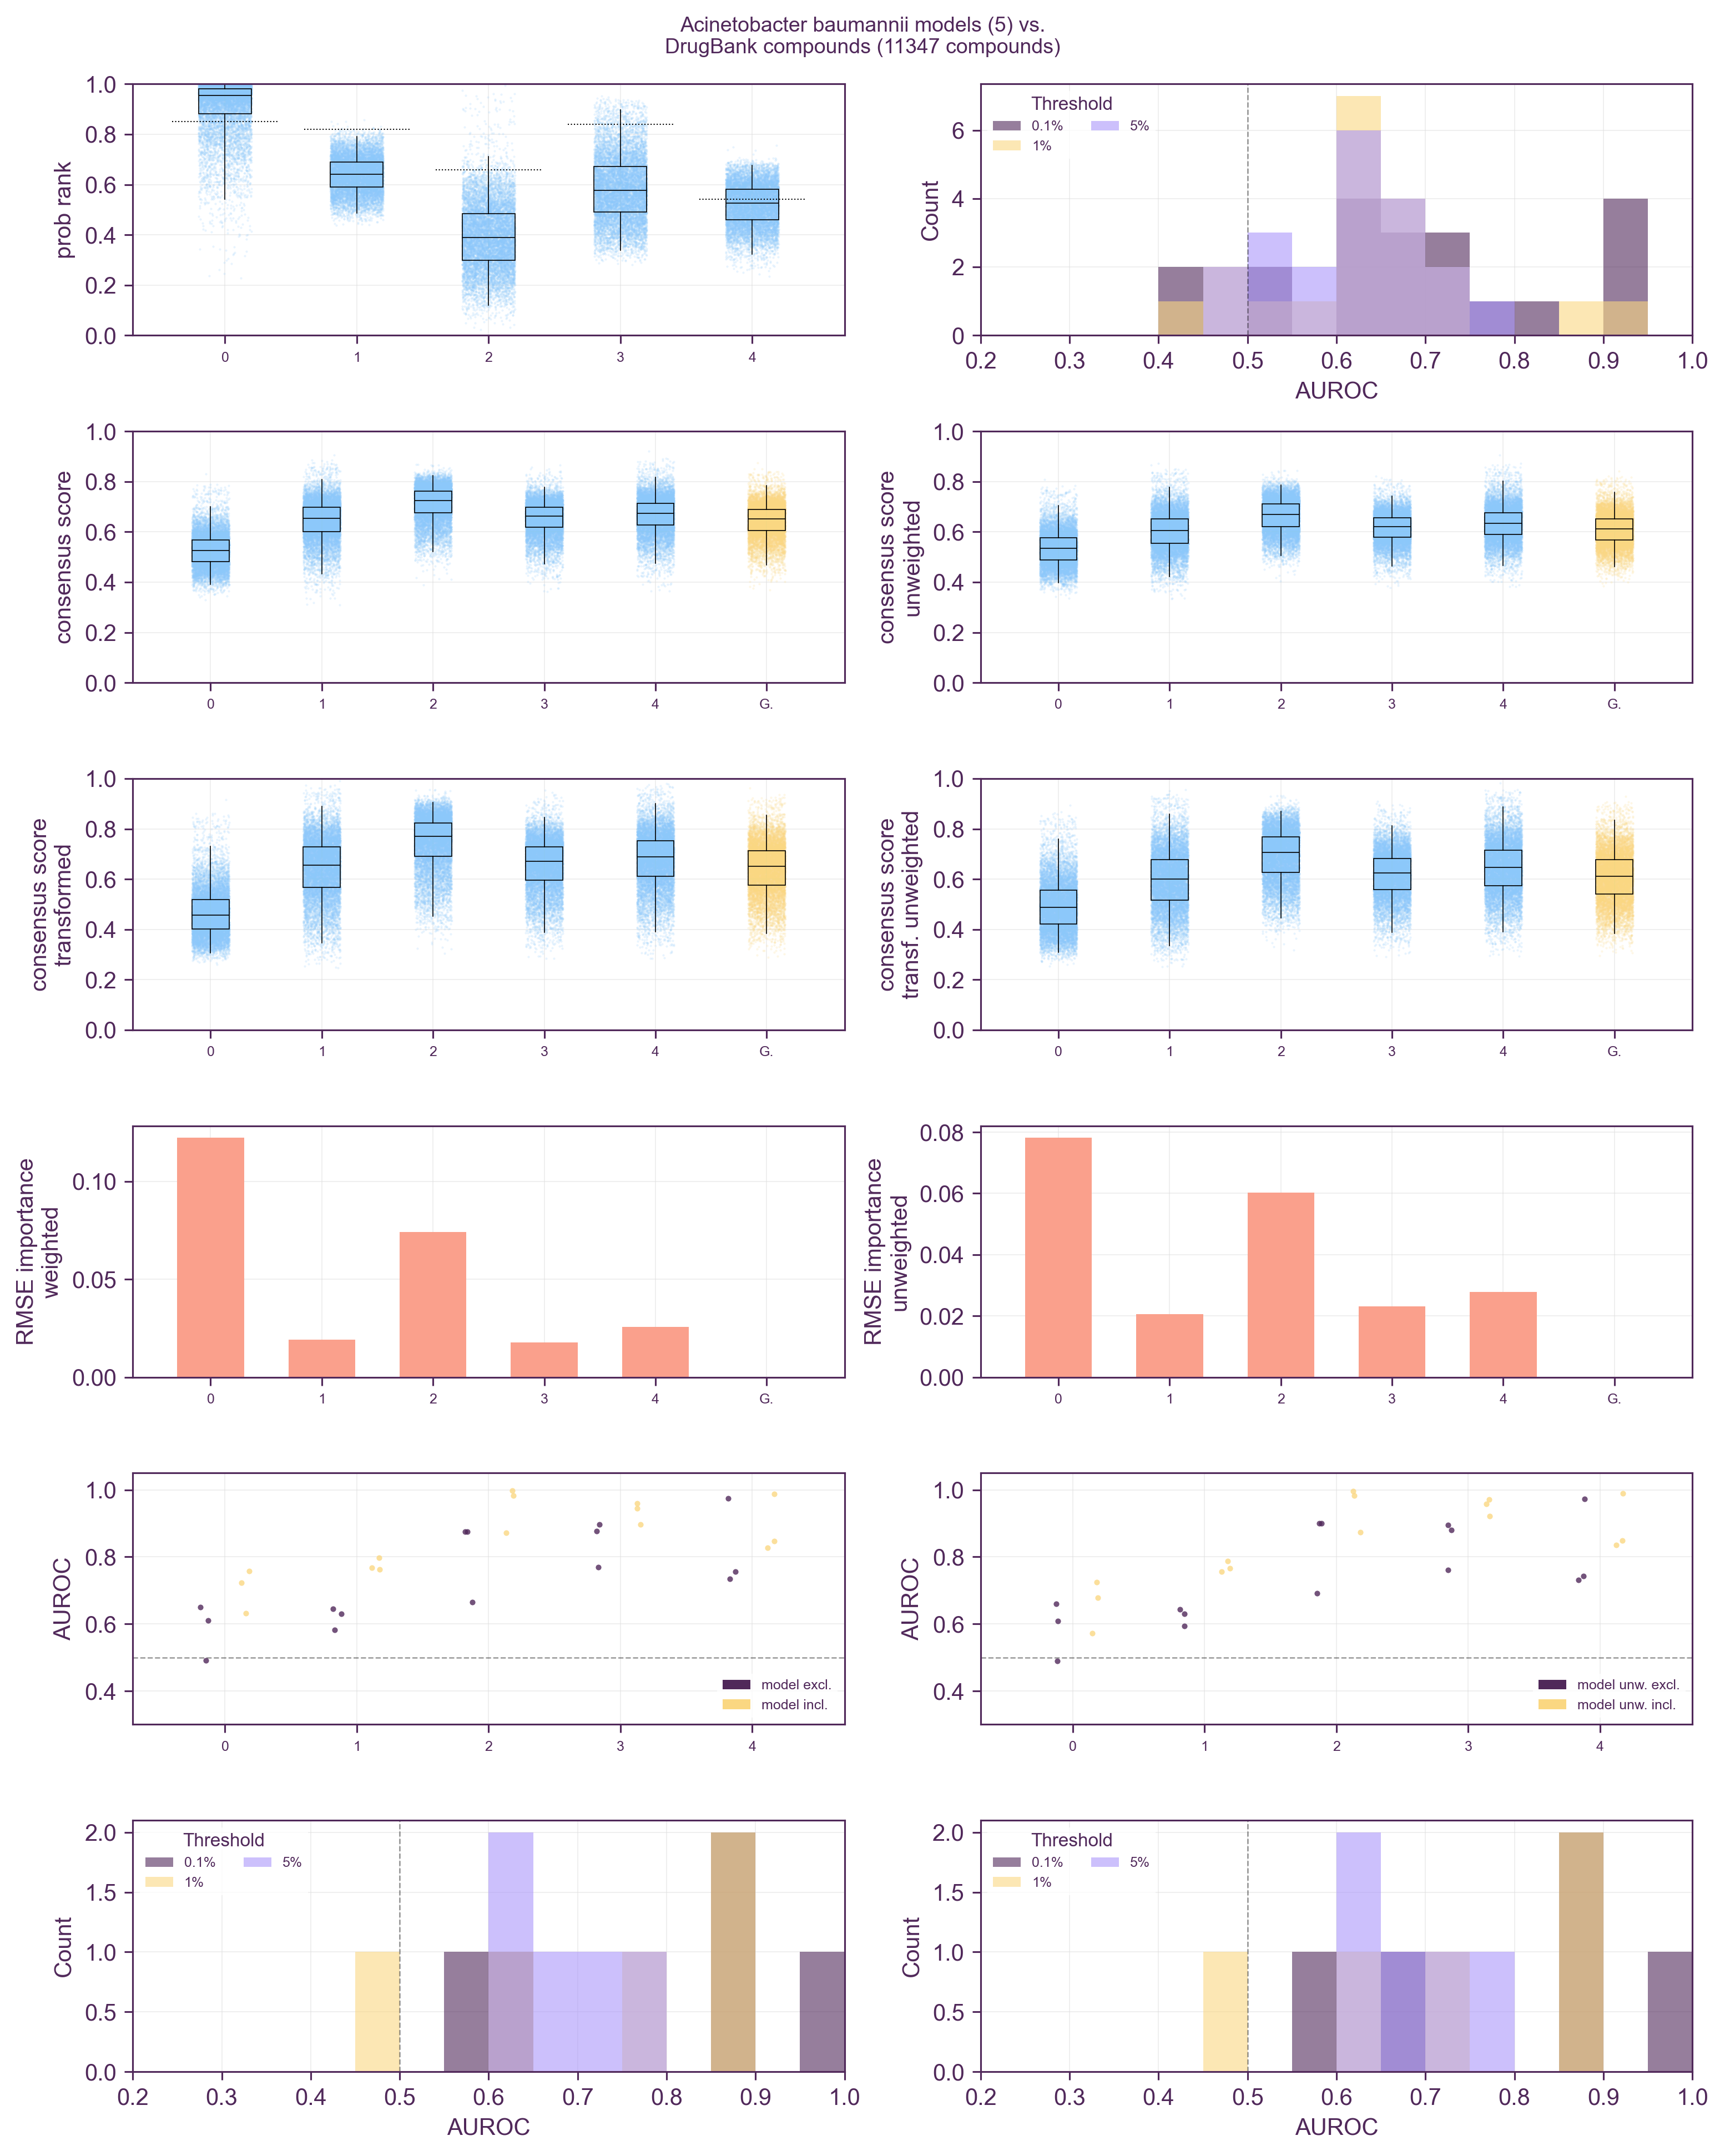

In [5]:
model_cols = [c for c in df12.columns if c != "smiles"]
report_p   = reports[reports["pathogen"] == pathogen].set_index("model_name")
N          = len(model_cols)
rng        = np.random.default_rng(42)
width      = 0.35
w          = min(0.35, max(0.15, 1.0 / N))


fig, axs = stylia.create_figure(6, 2, width=0.8, height=1)
fig.suptitle(f"{code_to_name[pathogen]} models ({N}) vs.\nDrugBank compounds ({len(df12)} compounds)", fontsize=9, y=0.99)

# ── [0] DrugBank prob_rank scores ──
ax = axs.next()
ax.set_ylabel("prob rank")
ax.set_ylim([0, 1])
ax.set_xlim([-0.7, N - 0.3])
for i, model in enumerate(model_cols):
    _plot_col(ax, df12[model].dropna().values, i, w, pal.get(8)[4])
    if model in report_p.index:
        c = report_p.loc[model, "decision_cutoff_rank"]
        ax.plot([i - w * 2, i + w * 2], [c, c], lw=0.5, c="k", linestyle="dotted")
ax.set_xticks(range(N))
ax.set_xticklabels([i for i in range(len(model_cols))], rotation=0, size=6)
ax.set_xlabel(None)

# ── [1] AUROC recapitulation — 3 thresholds ──
THRESH_COLS   = ["auroc_0.1pct", "auroc_1pct", "auroc_5pct"]
THRESH_LABELS = ["0.1%", "1%", "5%"]
df_recap_off  = df_recap_models[df_recap_models["model_scorer"] != df_recap_models["model_binarized"]]
colors        = pal.get(4)

ax = axs.next()
ax.set_xlabel("AUROC")
ax.set_ylabel("Count")
ax.set_xlim([0.2, 1])
bins = np.arange(0, 1.1, 0.05)
for col, label, color in zip(THRESH_COLS, THRESH_LABELS, colors):
    ax.hist(df_recap_off[col].dropna().values, bins=bins, alpha=0.6, label=label, color=color)
ax.axvline(0.5, lw=0.6, ls="--", color="k", alpha=0.4)
ax.legend(title="Threshold", fontsize=6, ncol=2, loc="upper left")

# ── [2] Consensus scores ──
ax = axs.next()
excl_cols = [c for c in df13_consensus.columns if c.startswith("excluded_")]
all_cols  = excl_cols + ["consensus_score"]
xlabels   = [c.replace("excluded_", "") for c in excl_cols] + ["global"]
xlabels = [i for i in range(len(excl_cols))] + ['G.']
NC  = len(all_cols)
w_c = min(0.35, max(0.15, 1.0 / NC))
ax.set_ylabel("consensus score")
ax.set_ylim([0, 1])
ax.set_xlim([-0.7, NC - 0.3])
for i, col in enumerate(all_cols):
    color = pal.get(2)[1] if col == "consensus_score" else pal.get(8)[4]
    _plot_col(ax, df13_consensus[col].dropna().values, i, w_c, color)
ax.set_xticks(range(NC))
ax.set_xticklabels(xlabels, rotation=0, size=6)
ax.set_xlabel(None)

# ── [3] Consensus scores unweighted ──
ax = axs.next()
excl_cols = [c for c in df13_consensus_unw.columns if c.startswith("excluded_")]
all_cols  = excl_cols + ["consensus_score"]
xlabels   = [c.replace("excluded_", "") for c in excl_cols] + ["global"]
xlabels = [i for i in range(len(excl_cols))] + ['G.']
NC  = len(all_cols)
w_c = min(0.35, max(0.15, 1.0 / NC))
ax.set_ylabel("consensus score\nunweighted")
ax.set_ylim([0, 1])
ax.set_xlim([-0.7, NC - 0.3])
for i, col in enumerate(all_cols):
    color = pal.get(2)[1] if col == "consensus_score" else pal.get(8)[4]
    _plot_col(ax, df13_consensus_unw[col].dropna().values, i, w_c, color)
ax.set_xticks(range(NC))
ax.set_xticklabels(xlabels, rotation=0, size=6)
ax.set_xlabel(None)

# ── [4] Consensus scores transformed ──
ax = axs.next()
excl_cols = [c for c in df13_consensus_transf.columns if c.startswith("excluded_")]
all_cols  = excl_cols + ["consensus_score"]
xlabels   = [c.replace("excluded_", "") for c in excl_cols] + ["global"]
xlabels = [i for i in range(len(excl_cols))] + ['G.']
NC  = len(all_cols)
w_c = min(0.35, max(0.15, 1.0 / NC))
ax.set_ylabel("consensus score\ntransformed")
ax.set_ylim([0, 1])
ax.set_xlim([-0.7, NC - 0.3])
for i, col in enumerate(all_cols):
    color = pal.get(2)[1] if col == "consensus_score" else pal.get(8)[4]
    _plot_col(ax, df13_consensus_transf[col].dropna().values, i, w_c, color)
ax.set_xticks(range(NC))
ax.set_xticklabels(xlabels, rotation=0, size=6)
ax.set_xlabel(None)

# ── [5] Consensus scores unweighted transformed ──
ax = axs.next()
excl_cols = [c for c in df13_consensus_unw_transf.columns if c.startswith("excluded_")]
all_cols  = excl_cols + ["consensus_score"]
xlabels   = [c.replace("excluded_", "") for c in excl_cols] + ["global"]
xlabels = [i for i in range(len(excl_cols))] + ['G.']
NC  = len(all_cols)
w_c = min(0.35, max(0.15, 1.0 / NC))
ax.set_ylabel("consensus score\ntransf. unweighted")
ax.set_ylim([0, 1])
ax.set_xlim([-0.7, NC - 0.3])
for i, col in enumerate(all_cols):
    color = pal.get(2)[1] if col == "consensus_score" else pal.get(8)[4]
    _plot_col(ax, df13_consensus_unw_transf[col].dropna().values, i, w_c, color)
ax.set_xticks(range(NC))
ax.set_xticklabels(xlabels, rotation=0, size=6)
ax.set_xlabel(None)

# ── [4] Consensus scores differnces (weighted) ──
ax = axs.next()
imp_w = _model_importance(df13_consensus, model_cols)
ax.bar(range(NC), imp_w, color=pal.get(8)[3], width=0.6)
ax.set_ylabel("RMSE importance\nweighted")
ax.set_xlim([-0.7, NC - 0.3])
ax.set_xticks(range(NC))
ax.set_xticklabels([i for i in range(NC-1)] + ['G.'], rotation=0, size=6)
ax.set_xlabel(None)

# ── [5] Consensus scores differnces (unweighted) ──
ax = axs.next()
imp_unw = _model_importance(df13_consensus_unw, model_cols)
ax.bar(range(NC), imp_unw, color=pal.get(8)[3], width=0.6)
ax.set_ylabel("RMSE importance\nunweighted")
ax.set_xlim([-0.7, NC - 0.3])
ax.set_xticks(range(NC))
ax.set_xticklabels([i for i in range(NC-1)] + ['G.'], rotation=0, size=6)
ax.set_xlabel(None)

# ── [6] AUROC recapitulation vs consensus ──
ax = axs.next()
AUROC_COLS = ["auroc_0.1pct", "auroc_1pct", "auroc_5pct"]
colors     = pal.get(2)
offset     = 0.15

ax.set_ylabel("AUROC")
ax.set_ylim([0.3, 1.05])
ax.set_xlim([-0.7, N - 0.3])
ax.axhline(0.5, lw=0.6, ls="--", color="k", alpha=0.4)

for i, model in enumerate(model_cols):
    for df, sign, color in [(df_recap_consensus_exc, -1, colors[0]),
                            (df_recap_consensus,     +1, colors[1])]:
        row = df[df["model"] == model]
        if not row.empty:
            vals = row[AUROC_COLS].values.flatten()
            xs   = [i + sign * offset + rng.uniform(-0.04, 0.04) for _ in vals]
            ax.scatter(xs, vals, color=color, s=6, alpha=0.8, lw=0, zorder=3)

ax.set_xticks(range(N))
ax.set_xticklabels(range(N), rotation=0, size=6)
ax.set_xlabel(None)
ax.legend(handles=[mpatches.Patch(color=c, label=l) for c, l in
                   zip(colors, ["model excl.", "model incl."])],
          fontsize=6, loc="lower right")


# ── [7] AUROC recapitulation vs consensus (unweighted) ──
ax = axs.next()
AUROC_COLS = ["auroc_0.1pct", "auroc_1pct", "auroc_5pct"]
colors     = pal.get(2)
offset     = 0.15

ax.set_ylabel("AUROC")
ax.set_ylim([0.3, 1.05])
ax.set_xlim([-0.7, N - 0.3])
ax.axhline(0.5, lw=0.6, ls="--", color="k", alpha=0.4)

for i, model in enumerate(model_cols):
    for df, sign, color in [(df_recap_consensus_exc_unw, -1, colors[0]),
                            (df_recap_consensus_unw,     +1, colors[1])]:
        row = df[df["model"] == model]
        if not row.empty:
            vals = row[AUROC_COLS].values.flatten()
            xs   = [i + sign * offset + rng.uniform(-0.04, 0.04) for _ in vals]
            ax.scatter(xs, vals, color=color, s=6, alpha=0.8, lw=0, zorder=3)

ax.set_xticks(range(N))
ax.set_xticklabels(range(N), rotation=0, size=6)
ax.set_xlabel(None)
ax.legend(handles=[mpatches.Patch(color=c, label=l) for c, l in
                   zip(colors, ["model unw. excl.", "model unw. incl."])],
          fontsize=6, loc="lower right")

# ── [8] AUROC recapitulation vs consensus ──
THRESH_COLS   = ["auroc_0.1pct", "auroc_1pct", "auroc_5pct"]
THRESH_LABELS = ["0.1%", "1%", "5%"]
colors        = pal.get(4)

ax = axs.next()
ax.set_xlabel("AUROC")
ax.set_ylabel("Count")
ax.set_xlim([0.2, 1])
bins = np.arange(0, 1.1, 0.05)
for col, label, color in zip(THRESH_COLS, THRESH_LABELS, colors):
    ax.hist(df_recap_consensus_exc[col].dropna().values, bins=bins, alpha=0.6, label=label, color=color)
ax.axvline(0.5, lw=0.6, ls="--", color="k", alpha=0.4)
ax.legend(title="Threshold", fontsize=6, ncol=2, loc="upper left")

# ── [9] AUROC recapitulation vs consensus (unweighted) ──
THRESH_COLS   = ["auroc_0.1pct", "auroc_1pct", "auroc_5pct"]
THRESH_LABELS = ["0.1%", "1%", "5%"]
colors        = pal.get(4)

ax = axs.next()
ax.set_xlabel("AUROC")
ax.set_ylabel("Count")
ax.set_xlim([0.2, 1])
bins = np.arange(0, 1.1, 0.05)
for col, label, color in zip(THRESH_COLS, THRESH_LABELS, colors):
    ax.hist(df_recap_consensus_exc_unw[col].dropna().values, bins=bins, alpha=0.6, label=label, color=color)
ax.axvline(0.5, lw=0.6, ls="--", color="k", alpha=0.4)
ax.legend(title="Threshold", fontsize=6, ncol=2, loc="upper left")


plt.show()